# Week 3 Hands-On: Traditional NLP Word Meaning Systems

**Practical Implementation of Lexicographic, Decompositional, and Ontological Approaches**

In this notebook, we'll implement working examples of the traditional approaches to word meaning covered in the lecture. This is **not** about modern machine learning - it's about understanding how symbolic NLP systems actually work in practice.

## 🎯 What You'll Build:
1. **Knowledge Graph Explorer** using Wikidata (like Google Knowledge Graph)
2. **WordNet Browser** with semantic similarity
3. **Simple LCS Parser** for verb meanings
4. **Mini Word Sense Disambiguation** system
5. **Ontology Reasoner** with inheritance

# DATA/MSML 641: Natural Language Processing
## Lecture 3 Lab: Traditional NLP Word Meaning Systems

<div style="display: flex; align-items: center; justify-content: space-between; margin: 40px 0;">
<div style="flex: 1;">

**University of Maryland, College Park**  
**Fall 2025**  
**Instructor**: Armin Mehrabian  
**Date**: September 15-16, 2025

**Hands-On Implementation Lab**

</div>
<div style="flex: 0 0 200px; text-align: right;">

<img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c" alt="UMD Logo" style="max-width: 200px; height: auto;" />

</div>
</div>

---

In [1]:
# Install required packages
!pip install nltk wikipedia-api requests networkx matplotlib seaborn pandas numpy SPARQLWrapper

# Download NLTK data
import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('stopwords', quiet=True)

import warnings
warnings.filterwarnings('ignore')

print("✅ Setup complete!")

✅ Setup complete!


[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1032)>
[nltk_data] Error loading omw-1.4: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1032)>
[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1032)>
[nltk_data] Error loading averaged_perceptron_tagger: <urlopen error
[nltk_data]     [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify
[nltk_data]     failed: unable to get local issuer certificate
[nltk_data]     (_ssl.c:1032)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate 

---

# 🌐 Part 1: Knowledge Graph Explorer (Wikidata)

Let's build a system that queries **Wikidata** (the knowledge graph behind Wikipedia) to understand how ontological approaches work in practice. This is similar to how Google's Knowledge Graph operates.

In [2]:
from SPARQLWrapper import SPARQLWrapper, JSON
import pandas as pd
import requests
import json

class WikidataKnowledgeGraph:
    """A practical implementation of knowledge graph queries"""
    
    def __init__(self):
        self.sparql = SPARQLWrapper("https://query.wikidata.org/sparql")
        self.sparql.setReturnFormat(JSON)
        
    def search_entity(self, query, limit=5):
        """Search for entities in Wikidata"""
        url = "https://www.wikidata.org/w/api.php"
        params = {
            'action': 'wbsearchentities',
            'search': query,
            'language': 'en',
            'format': 'json',
            'limit': limit
        }
        
        try:
            response = requests.get(url, params=params)
            data = response.json()
            
            results = []
            for item in data.get('search', []):
                results.append({
                    'id': item['id'],
                    'label': item.get('label', ''),
                    'description': item.get('description', ''),
                    'url': item.get('url', '')
                })
            
            return results
        except Exception as e:
            print(f"Error searching: {e}")
            return []
    
    def get_is_a_hierarchy(self, entity_id, depth=3):
        """Get the IS-A hierarchy for an entity (like 'dog IS-A mammal IS-A animal')"""
        query = f"""
        SELECT ?item ?itemLabel ?parent ?parentLabel WHERE {{
          wd:{entity_id} wdt:P31*/wdt:P279* ?item .
          OPTIONAL {{
            ?item wdt:P279 ?parent .
          }}
          SERVICE wikibase:label {{ bd:serviceParam wikibase:language "en". }}
        }}
        LIMIT 20
        """
        
        try:
            self.sparql.setQuery(query)
            results = self.sparql.query().convert()
            
            hierarchy = []
            for result in results["results"]["bindings"]:
                item_label = result.get("itemLabel", {}).get("value", "")
                parent_label = result.get("parentLabel", {}).get("value", "")
                
                if item_label and parent_label:
                    hierarchy.append({
                        'concept': item_label,
                        'parent': parent_label,
                        'relation': 'IS-A'
                    })
            
            return hierarchy
        except Exception as e:
            print(f"Error getting hierarchy: {e}")
            return []
    
    def get_properties(self, entity_id, limit=10):
        """Get key properties of an entity"""
        query = f"""
        SELECT ?property ?propertyLabel ?value ?valueLabel WHERE {{
          wd:{entity_id} ?property ?value .
          ?prop wikibase:directClaim ?property .
          SERVICE wikibase:label {{ bd:serviceParam wikibase:language "en". }}
        }}
        LIMIT {limit}
        """
        
        try:
            self.sparql.setQuery(query)
            results = self.sparql.query().convert()
            
            properties = []
            for result in results["results"]["bindings"]:
                prop_label = result.get("propertyLabel", {}).get("value", "")
                value_label = result.get("valueLabel", {}).get("value", "")
                
                if prop_label and value_label and len(value_label) < 100:  # Filter long values
                    properties.append({
                        'property': prop_label,
                        'value': value_label
                    })
            
            return properties[:limit]
        except Exception as e:
            print(f"Error getting properties: {e}")
            return []

# Create knowledge graph instance
kg = WikidataKnowledgeGraph()
print("🔍 Knowledge Graph Explorer ready!")

🔍 Knowledge Graph Explorer ready!


In [3]:
# Demo: Explore "Apple Inc." vs "Apple (fruit)"
print("🔍 Searching for 'Apple' entities...\n")

apple_entities = kg.search_entity("Apple", limit=10)

for i, entity in enumerate(apple_entities):
    print(f"{i+1}. {entity['label']}")
    print(f"   Description: {entity['description']}")
    print(f"   Wikidata ID: {entity['id']}")
    print()

print("💡 Notice how the knowledge graph distinguishes different senses of 'Apple'!")
print("This is exactly the challenge we discussed in lexicographic approaches.")

🔍 Searching for 'Apple' entities...

Error searching: Expecting value: line 1 column 1 (char 0)
💡 Notice how the knowledge graph distinguishes different senses of 'Apple'!
This is exactly the challenge we discussed in lexicographic approaches.


In [4]:
# Demo: Get IS-A hierarchy for "Dog"
print("🐕 Exploring the IS-A hierarchy for 'Dog'...\n")

# First find the dog entity
dog_entities = kg.search_entity("Dog", limit=3)
if dog_entities:
    dog_id = dog_entities[0]['id']  # Usually Q144 for domestic dog
    print(f"Using entity: {dog_entities[0]['label']} ({dog_id})\n")
    
    # Get the hierarchy
    hierarchy = kg.get_is_a_hierarchy(dog_id)
    
    print("📊 IS-A Relationships:")
    print("=" * 30)
    
    # Display unique relationships
    seen = set()
    for item in hierarchy:
        relationship = f"{item['concept']} IS-A {item['parent']}"
        if relationship not in seen and len(relationship) < 80:
            print(f"• {relationship}")
            seen.add(relationship)
    
    print("\n💡 This shows property inheritance: dogs inherit all properties of mammals, animals, etc.")
else:
    print("❌ Could not find dog entity")

🐕 Exploring the IS-A hierarchy for 'Dog'...

Error searching: Expecting value: line 1 column 1 (char 0)
❌ Could not find dog entity


In [5]:
# Interactive: Let students explore any concept
def explore_concept(concept_name):
    """Interactive function to explore any concept"""
    print(f"🔍 Exploring: {concept_name}\n")
    
    # Search for the concept
    entities = kg.search_entity(concept_name, limit=3)
    
    if not entities:
        print("❌ No entities found")
        return
    
    # Use the first entity
    entity = entities[0]
    print(f"📋 Entity: {entity['label']}")
    print(f"📝 Description: {entity['description']}\n")
    
    # Get properties
    properties = kg.get_properties(entity['id'], limit=8)
    if properties:
        print("🏷️  Key Properties:")
        for prop in properties[:5]:  # Show top 5
            print(f"   • {prop['property']}: {prop['value']}")
    
    print("\n" + "="*50)

# Try different concepts
concepts_to_explore = ["Python programming language", "University of Maryland", "Jazz music"]

for concept in concepts_to_explore:
    explore_concept(concept)
    print()

🔍 Exploring: Python programming language

Error searching: Expecting value: line 1 column 1 (char 0)
❌ No entities found

🔍 Exploring: University of Maryland

Error searching: Expecting value: line 1 column 1 (char 0)
❌ No entities found

🔍 Exploring: Jazz music

Error searching: Expecting value: line 1 column 1 (char 0)
❌ No entities found



---

# 📖 Part 2: WordNet Browser (Lexicographic Approach)

Let's build a practical WordNet explorer to understand how lexicographic approaches organize word meanings.

In [6]:
from nltk.corpus import wordnet as wn
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict

class WordNetExplorer:
    """Practical WordNet interface for exploring lexicographic organization"""
    
    def __init__(self):
        self.stop_words = set(stopwords.words('english'))
    
    def explore_word_senses(self, word):
        """Show all senses of a word with examples and definitions"""
        synsets = wn.synsets(word)
        
        if not synsets:
            print(f"❌ No synsets found for '{word}'")
            return []
        
        print(f"🔍 Word: '{word}' has {len(synsets)} sense(s)\n")
        
        sense_info = []
        for i, synset in enumerate(synsets, 1):
            print(f"📋 Sense {i}: {synset.name()}")
            print(f"   Definition: {synset.definition()}")
            
            # Show examples
            if synset.examples():
                print(f"   Examples: {'; '.join(synset.examples()[:2])}")
            
            # Show synonyms
            synonyms = [lemma.name().replace('_', ' ') for lemma in synset.lemmas()]
            print(f"   Synonyms: {', '.join(synonyms)}")
            
            # Show hypernyms (IS-A parents)
            hypernyms = [hyp.name().split('.')[0] for hyp in synset.hypernyms()]
            if hypernyms:
                print(f"   IS-A: {', '.join(hypernyms)}")
            
            print()
            
            sense_info.append({
                'synset': synset,
                'definition': synset.definition(),
                'examples': synset.examples(),
                'synonyms': synonyms
            })
        
        return sense_info
    
    def compare_word_similarity(self, word1, word2):
        """Compare semantic similarity between two words using WordNet"""
        synsets1 = wn.synsets(word1)
        synsets2 = wn.synsets(word2)
        
        if not synsets1 or not synsets2:
            print(f"❌ Could not find synsets for '{word1}' or '{word2}'")
            return 0.0
        
        # Find best similarity score
        max_similarity = 0.0
        best_pair = None
        
        for s1 in synsets1:
            for s2 in synsets2:
                similarity = s1.path_similarity(s2)
                if similarity and similarity > max_similarity:
                    max_similarity = similarity
                    best_pair = (s1, s2)
        
        print(f"🔗 Similarity between '{word1}' and '{word2}': {max_similarity:.3f}")
        
        if best_pair:
            print(f"   Best match: {best_pair[0].definition()}")
            print(f"             ↔ {best_pair[1].definition()}")
        
        return max_similarity
    
    def build_semantic_network(self, words, similarity_threshold=0.3):
        """Build a network showing semantic relationships between words"""
        G = nx.Graph()
        similarities = {}
        
        # Add nodes
        for word in words:
            G.add_node(word)
        
        # Add edges based on similarity
        for i, word1 in enumerate(words):
            for word2 in words[i+1:]:
                similarity = self._get_similarity_score(word1, word2)
                if similarity > similarity_threshold:
                    G.add_edge(word1, word2, weight=similarity)
                    similarities[(word1, word2)] = similarity
        
        return G, similarities
    
    def _get_similarity_score(self, word1, word2):
        """Get similarity score between two words"""
        synsets1 = wn.synsets(word1)
        synsets2 = wn.synsets(word2)
        
        if not synsets1 or not synsets2:
            return 0.0
        
        max_similarity = 0.0
        for s1 in synsets1:
            for s2 in synsets2:
                similarity = s1.path_similarity(s2)
                if similarity:
                    max_similarity = max(max_similarity, similarity)
        
        return max_similarity
    
    def visualize_network(self, G, similarities, title="Semantic Network"):
        """Visualize the semantic network"""
        plt.figure(figsize=(12, 8))
        
        # Layout
        pos = nx.spring_layout(G, k=2, iterations=50)
        
        # Draw edges with thickness based on similarity
        for edge in G.edges():
            word1, word2 = edge
            similarity = similarities.get((word1, word2), similarities.get((word2, word1), 0))
            nx.draw_networkx_edges(G, pos, edgelist=[edge], 
                                 width=similarity*5, alpha=0.6, edge_color='gray')
        
        # Draw nodes
        nx.draw_networkx_nodes(G, pos, node_color='lightblue', 
                             node_size=3000, alpha=0.8)
        
        # Draw labels
        nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
        
        plt.title(title, fontsize=14, fontweight='bold')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
        # Print edge weights
        print("🔗 Similarity Scores:")
        for (word1, word2), sim in sorted(similarities.items(), key=lambda x: x[1], reverse=True):
            print(f"   {word1} ↔ {word2}: {sim:.3f}")

# Create WordNet explorer
wordnet_explorer = WordNetExplorer()
print("📖 WordNet Explorer ready!")

📖 WordNet Explorer ready!


In [7]:
# Demo: Explore "bass" - the classic ambiguous word
wordnet_explorer.explore_word_senses("bass")

🔍 Word: 'bass' has 9 sense(s)

📋 Sense 1: bass.n.01
   Definition: the lowest part of the musical range
   Synonyms: bass
   IS-A: pitch

📋 Sense 2: bass.n.02
   Definition: the lowest part in polyphonic music
   Synonyms: bass, bass part
   IS-A: part

📋 Sense 3: bass.n.03
   Definition: an adult male singer with the lowest voice
   Synonyms: bass, basso
   IS-A: singer

📋 Sense 4: sea_bass.n.01
   Definition: the lean flesh of a saltwater fish of the family Serranidae
   Synonyms: sea bass, bass
   IS-A: saltwater_fish

📋 Sense 5: freshwater_bass.n.01
   Definition: any of various North American freshwater fish with lean flesh (especially of the genus Micropterus)
   Synonyms: freshwater bass, bass
   IS-A: freshwater_fish

📋 Sense 6: bass.n.06
   Definition: the lowest adult male singing voice
   Synonyms: bass, bass voice, basso
   IS-A: singing_voice

📋 Sense 7: bass.n.07
   Definition: the member with the lowest range of a family of musical instruments
   Synonyms: bass
   IS-A: 

[{'synset': Synset('bass.n.01'),
  'definition': 'the lowest part of the musical range',
  'examples': [],
  'synonyms': ['bass']},
 {'synset': Synset('bass.n.02'),
  'definition': 'the lowest part in polyphonic music',
  'examples': [],
  'synonyms': ['bass', 'bass part']},
 {'synset': Synset('bass.n.03'),
  'definition': 'an adult male singer with the lowest voice',
  'examples': [],
  'synonyms': ['bass', 'basso']},
 {'synset': Synset('sea_bass.n.01'),
  'definition': 'the lean flesh of a saltwater fish of the family Serranidae',
  'examples': [],
  'synonyms': ['sea bass', 'bass']},
 {'synset': Synset('freshwater_bass.n.01'),
  'definition': 'any of various North American freshwater fish with lean flesh (especially of the genus Micropterus)',
  'examples': [],
  'synonyms': ['freshwater bass', 'bass']},
 {'synset': Synset('bass.n.06'),
  'definition': 'the lowest adult male singing voice',
  'examples': [],
  'synonyms': ['bass', 'bass voice', 'basso']},
 {'synset': Synset('bass.n.

In [8]:
# Demo: Compare word similarities
word_pairs = [
    ("dog", "cat"),
    ("dog", "animal"),
    ("car", "vehicle"),
    ("bass", "guitar"),
    ("bass", "fish")
]

print("🔍 Word Similarity Comparisons:\n")
for word1, word2 in word_pairs:
    wordnet_explorer.compare_word_similarity(word1, word2)
    print()


🔍 Word Similarity Comparisons:

🔗 Similarity between 'dog' and 'cat': 0.200
   Best match: a member of the genus Canis (probably descended from the common wolf) that has been domesticated by man since prehistoric times; occurs in many breeds
             ↔ feline mammal usually having thick soft fur and no ability to roar: domestic cats; wildcats

🔗 Similarity between 'dog' and 'animal': 0.333
   Best match: a member of the genus Canis (probably descended from the common wolf) that has been domesticated by man since prehistoric times; occurs in many breeds
             ↔ a living organism characterized by voluntary movement

🔗 Similarity between 'car' and 'vehicle': 0.333
   Best match: a wheeled vehicle adapted to the rails of railroad
             ↔ a conveyance that transports people or objects

🔗 Similarity between 'bass' and 'guitar': 0.250
   Best match: the member with the lowest range of a family of musical instruments
             ↔ a stringed instrument usually having six str

🕸️ Building semantic network for animal words...



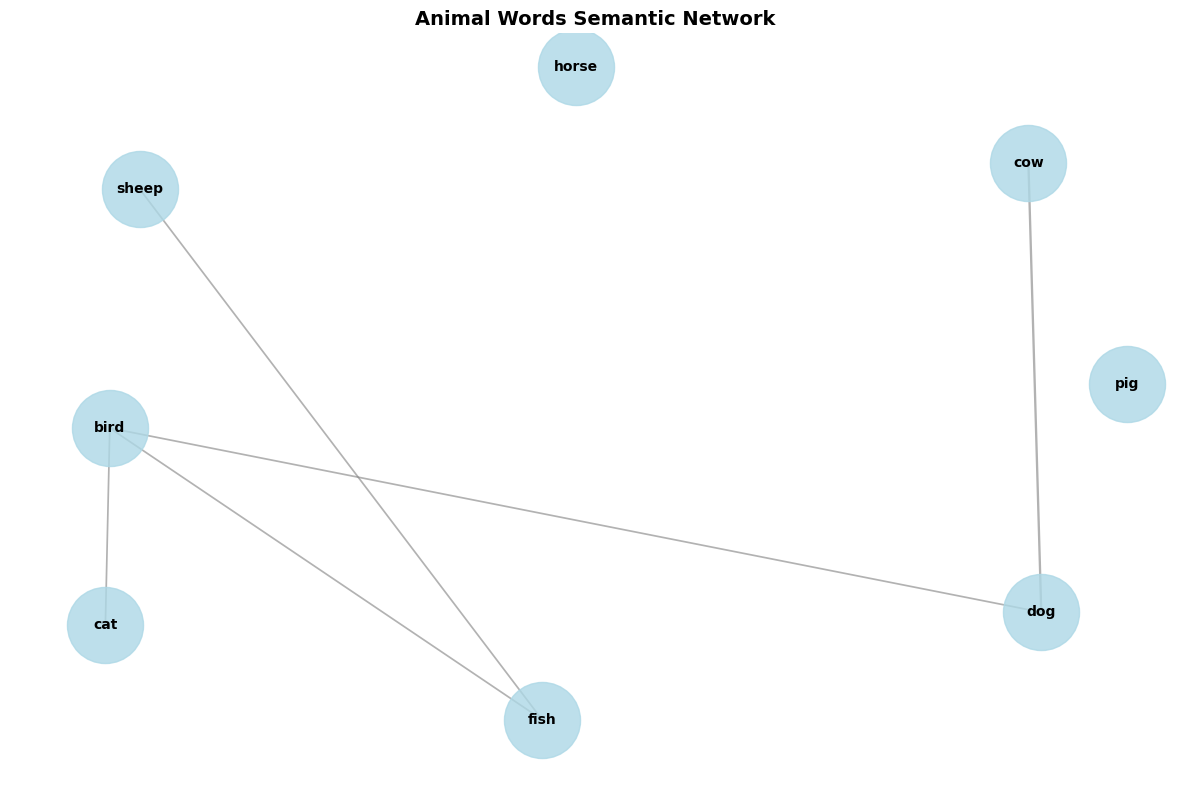

🔗 Similarity Scores:
   dog ↔ cow: 0.333
   dog ↔ bird: 0.250
   cat ↔ bird: 0.250
   fish ↔ bird: 0.250
   fish ↔ sheep: 0.250


In [9]:
# Demo: Build and visualize a semantic network
animal_words = ["dog", "cat", "fish", "bird", "horse", "cow", "pig", "sheep"]

print("🕸️ Building semantic network for animal words...\n")
G, similarities = wordnet_explorer.build_semantic_network(animal_words, similarity_threshold=0.2)

wordnet_explorer.visualize_network(G, similarities, "Animal Words Semantic Network")

---

# 🔧 Part 3: Simple LCS Parser (Decompositional Approach)

Let's implement a basic Lexical Conceptual Structure parser that decomposes verb meanings into semantic primitives, following Ray Jackendoff's approach.

In [10]:
import re
from nltk import word_tokenize, pos_tag

class SimpleLCSParser:
    """Basic implementation of Lexical Conceptual Structure parsing"""
    
    def __init__(self):
        # Define LCS templates for common verbs
        self.verb_templates = {
            # Motion and transfer verbs
            'give': 'CAUSE({agent}, GO({theme}, TO({recipient})))',
            'take': 'CAUSE({agent}, GO({theme}, FROM({source}), TO({agent})))',
            'bring': 'CAUSE({agent}, GO({theme}, TO(HERE)))',
            'send': 'CAUSE({agent}, GO({theme}, TO({recipient})))',
            'put': 'CAUSE({agent}, GO({theme}, TO({location})))',
            'move': 'GO({theme}, FROM({source}), TO({destination}))',
            
            # State change verbs
            'break': 'CAUSE({agent}, BECOME({theme}, BROKEN))',
            'open': 'CAUSE({agent}, BECOME({theme}, OPEN))',
            'close': 'CAUSE({agent}, BECOME({theme}, CLOSED))',
            'kill': 'CAUSE({agent}, BECOME({theme}, DEAD))',
            
            # Creation/destruction verbs  
            'make': 'CAUSE({agent}, COME_TO_EXIST({theme}))',
            'build': 'CAUSE({agent}, COME_TO_EXIST({theme}))',
            'destroy': 'CAUSE({agent}, CEASE_TO_EXIST({theme}))',
            
            # Psychological verbs
            'see': 'PERCEIVE({experiencer}, {theme})',
            'hear': 'PERCEIVE({experiencer}, {theme})',
            'know': 'STATE({experiencer}, KNOW({theme}))',
            'believe': 'STATE({experiencer}, BELIEVE({theme}))'
        }
        
        # Semantic role patterns (simplified)
        self.role_patterns = {
            'agent': ['agent', 'causer', 'actor'],
            'theme': ['theme', 'patient', 'object'],
            'recipient': ['recipient', 'goal', 'beneficiary'],
            'source': ['source', 'origin'],
            'location': ['location', 'place'],
            'experiencer': ['experiencer', 'perceiver']
        }
    
    def parse_sentence(self, sentence):
        """Parse a sentence and extract LCS representation"""
        tokens = word_tokenize(sentence.lower())
        pos_tags = pos_tag(tokens)
        
        # Find main verb
        main_verb = None
        for word, pos in pos_tags:
            if pos.startswith('VB') and word in self.verb_templates:
                main_verb = word
                break
        
        if not main_verb:
            return None, "No recognized verb found"
        
        # Extract arguments (simplified - real parser would be much more complex)
        arguments = self._extract_arguments(tokens, pos_tags, main_verb)
        
        # Get LCS template
        template = self.verb_templates[main_verb]
        
        # Fill in template
        lcs_repr = self._fill_template(template, arguments)
        
        return {
            'sentence': sentence,
            'verb': main_verb,
            'template': template,
            'arguments': arguments,
            'lcs': lcs_repr
        }, None
    
    def _extract_arguments(self, tokens, pos_tags, verb):
        """Extract semantic arguments (simplified extraction)"""
        arguments = {}
        
        # Find verb position
        verb_idx = None
        for i, (word, pos) in enumerate(pos_tags):
            if word == verb:
                verb_idx = i
                break
        
        if verb_idx is None:
            return arguments
        
        # Extract subject (before verb)
        for i in range(verb_idx):
            word, pos = pos_tags[i]
            if pos.startswith('NN') or pos.startswith('PRP'):
                arguments['agent'] = word
                break
        
        # Extract object (after verb)
        for i in range(verb_idx + 1, len(pos_tags)):
            word, pos = pos_tags[i]
            if pos.startswith('NN') and 'theme' not in arguments:
                arguments['theme'] = word
            elif word == 'to' and i + 1 < len(pos_tags):
                next_word, next_pos = pos_tags[i + 1]
                if next_pos.startswith('NN') or next_pos.startswith('PRP'):
                    arguments['recipient'] = next_word
            elif word == 'from' and i + 1 < len(pos_tags):
                next_word, next_pos = pos_tags[i + 1]
                if next_pos.startswith('NN'):
                    arguments['source'] = next_word
        
        return arguments
    
    def _fill_template(self, template, arguments):
        """Fill LCS template with extracted arguments"""
        filled = template
        for role, value in arguments.items():
            placeholder = f"{{{role}}}"
            filled = filled.replace(placeholder, value.upper())
        
        # Replace unfilled placeholders
        filled = re.sub(r'\{[^}]+\}', '?', filled)
        
        return filled
    
    def compare_verbs(self, verbs):
        """Compare LCS structures of multiple verbs"""
        print("🔄 LCS Verb Comparison:")
        print("=" * 40)
        
        for verb in verbs:
            if verb in self.verb_templates:
                template = self.verb_templates[verb]
                print(f"{verb:12} → {template}")
            else:
                print(f"{verb:12} → (not in database)")
        
        print("\n💡 Notice the systematic relationships between verbs!")
    
    def analyze_verb_classes(self):
        """Analyze verb classes based on LCS patterns"""
        classes = defaultdict(list)
        
        for verb, template in self.verb_templates.items():
            if 'CAUSE' in template and 'GO' in template:
                classes['Causative Motion'].append(verb)
            elif 'CAUSE' in template and 'BECOME' in template:
                classes['Causative Change'].append(verb)
            elif 'GO' in template:
                classes['Motion'].append(verb)
            elif 'PERCEIVE' in template:
                classes['Perception'].append(verb)
            elif 'STATE' in template:
                classes['Psychological State'].append(verb)
            else:
                classes['Other'].append(verb)
        
        print("📊 Verb Classes by LCS Patterns:")
        print("=" * 40)
        
        for class_name, verbs in classes.items():
            print(f"\n{class_name}:")
            for verb in verbs:
                print(f"  • {verb}")

# Create LCS parser
lcs_parser = SimpleLCSParser()
print("🔧 LCS Parser ready!")

🔧 LCS Parser ready!


In [11]:
# Demo: Parse example sentences
test_sentences = [
    "John gave Mary the book",
    "Sarah took the keys from Tom",
    "The robot put the box on the table",
    "Alice broke the window",
    "Bob built a house"
]

print("🔍 LCS Sentence Analysis:")
print("=" * 60)

for sentence in test_sentences:
    result, error = lcs_parser.parse_sentence(sentence)
    
    if result:
        print(f"\n📝 Sentence: {result['sentence']}")
        print(f"🎯 Verb: {result['verb']}")
        print(f"📋 Template: {result['template']}")
        print(f"🔧 Arguments: {result['arguments']}")
        print(f"⚡ LCS: {result['lcs']}")
    else:
        print(f"\n❌ {sentence}: {error}")

print("\n💡 Notice how different surface forms map to systematic semantic patterns!")

🔍 LCS Sentence Analysis:

❌ John gave Mary the book: No recognized verb found

❌ Sarah took the keys from Tom: No recognized verb found

📝 Sentence: The robot put the box on the table
🎯 Verb: put
📋 Template: CAUSE({agent}, GO({theme}, TO({location})))
🔧 Arguments: {'agent': 'robot', 'theme': 'box'}
⚡ LCS: CAUSE(ROBOT, GO(BOX, TO(?)))

❌ Alice broke the window: No recognized verb found

❌ Bob built a house: No recognized verb found

💡 Notice how different surface forms map to systematic semantic patterns!


In [12]:
# Demo: Compare verb structures
lcs_parser.compare_verbs(['give', 'take', 'send', 'bring'])
print()
lcs_parser.analyze_verb_classes()

🔄 LCS Verb Comparison:
give         → CAUSE({agent}, GO({theme}, TO({recipient})))
take         → CAUSE({agent}, GO({theme}, FROM({source}), TO({agent})))
send         → CAUSE({agent}, GO({theme}, TO({recipient})))
bring        → CAUSE({agent}, GO({theme}, TO(HERE)))

💡 Notice the systematic relationships between verbs!

📊 Verb Classes by LCS Patterns:

Causative Motion:
  • give
  • take
  • bring
  • send
  • put

Motion:
  • move

Causative Change:
  • break
  • open
  • close
  • kill

Other:
  • make
  • build
  • destroy

Perception:
  • see
  • hear

Psychological State:
  • know
  • believe


---

# 🎯 Part 4: Simple Word Sense Disambiguation

Let's build a basic WSD system using context clues and frequency information.

In [13]:
from collections import Counter, defaultdict
import math

class SimpleWSD:
    """Simple Word Sense Disambiguation using context patterns and frequency"""
    
    def __init__(self):
        # Predefined sense inventories for demo
        self.word_senses = {
            'bank': {
                'financial': {
                    'definition': 'financial institution',
                    'context_words': ['money', 'account', 'loan', 'credit', 'deposit', 'withdrawal', 
                                    'atm', 'branch', 'customer', 'interest', 'mortgage', 'savings']
                },
                'river': {
                    'definition': 'edge of a river or lake',
                    'context_words': ['river', 'water', 'shore', 'fishing', 'boat', 'swim', 
                                    'edge', 'stream', 'lake', 'flow', 'bridge']
                }
            },
            'bass': {
                'music': {
                    'definition': 'low-pitched musical instrument or voice',
                    'context_words': ['guitar', 'music', 'play', 'song', 'band', 'voice', 'sing',
                                    'notes', 'sound', 'instrument', 'chord', 'melody']
                },
                'fish': {
                    'definition': 'type of freshwater fish',
                    'context_words': ['fish', 'fishing', 'catch', 'lake', 'water', 'angler',
                                    'rod', 'bait', 'hook', 'stream', 'river', 'species']
                }
            },
            'apple': {
                'fruit': {
                    'definition': 'edible fruit',
                    'context_words': ['eat', 'fruit', 'red', 'green', 'sweet', 'tree', 'orchard',
                                    'juice', 'pie', 'food', 'healthy', 'fresh']
                },
                'company': {
                    'definition': 'technology company',
                    'context_words': ['iphone', 'mac', 'computer', 'technology', 'steve', 'jobs',
                                    'ipad', 'software', 'company', 'corporation', 'stock']
                }
            }
        }
        
        # Sense frequencies (Most Frequent Sense baseline)
        self.sense_frequencies = {
            'bank': {'financial': 0.8, 'river': 0.2},
            'bass': {'music': 0.6, 'fish': 0.4},
            'apple': {'fruit': 0.3, 'company': 0.7}  # Apple Inc. is very common in text
        }
    
    def get_most_frequent_sense(self, word):
        """Return the most frequent sense (strong baseline)"""
        if word not in self.sense_frequencies:
            return None, "Word not in database"
        
        frequencies = self.sense_frequencies[word]
        most_frequent = max(frequencies.items(), key=lambda x: x[1])
        
        return most_frequent[0], f"Frequency: {most_frequent[1]}"
    
    def disambiguate_by_context(self, sentence, target_word, window=5):
        """Disambiguate using context word overlap"""
        if target_word not in self.word_senses:
            return None, "Word not in sense inventory"
        
        # Extract context words
        words = sentence.lower().split()
        
        # Find target word position
        target_positions = [i for i, w in enumerate(words) if target_word.lower() in w.lower()]
        
        if not target_positions:
            return None, f"Target word '{target_word}' not found in sentence"
        
        # Extract context window around target word
        target_pos = target_positions[0]
        start = max(0, target_pos - window)
        end = min(len(words), target_pos + window + 1)
        context_words = set(words[start:target_pos] + words[target_pos+1:end])
        
        # Score each sense based on context overlap
        sense_scores = {}
        senses = self.word_senses[target_word]
        
        for sense_name, sense_info in senses.items():
            sense_context = set(sense_info['context_words'])
            
            # Calculate overlap score
            overlap = len(context_words.intersection(sense_context))
            
            # Add frequency prior (Bayesian approach)
            prior = self.sense_frequencies[target_word][sense_name]
            
            # Combined score (context + frequency)
            score = overlap + math.log(prior)
            sense_scores[sense_name] = {
                'score': score,
                'context_overlap': overlap,
                'overlapping_words': list(context_words.intersection(sense_context)),
                'prior': prior
            }
        
        # Choose best sense
        best_sense = max(sense_scores.items(), key=lambda x: x[1]['score'])
        
        return best_sense[0], sense_scores
    
    def explain_decision(self, sentence, target_word):
        """Provide detailed explanation of disambiguation decision"""
        print(f"🔍 Disambiguating '{target_word}' in: {sentence}\n")
        
        # Most frequent sense baseline
        mfs, mfs_info = self.get_most_frequent_sense(target_word)
        print(f"📊 Most Frequent Sense: {mfs} ({mfs_info})")
        
        # Context-based disambiguation
        best_sense, scores = self.disambiguate_by_context(sentence, target_word)
        
        if best_sense:
            print(f"\n🎯 Context-based Decision: {best_sense}")
            print(f"   Definition: {self.word_senses[target_word][best_sense]['definition']}\n")
            
            print("📋 Detailed Scoring:")
            for sense, score_info in scores.items():
                print(f"\n   {sense.upper()}:")
                print(f"      Context overlap: {score_info['context_overlap']} words")
                print(f"      Overlapping words: {score_info['overlapping_words']}")
                print(f"      Frequency prior: {score_info['prior']:.2f}")
                print(f"      Total score: {score_info['score']:.2f}")
            
            # Compare with baseline
            if best_sense == mfs:
                print(f"\n✅ Context confirms most frequent sense!")
            else:
                print(f"\n⚡ Context overrides frequency! ({mfs} → {best_sense})")
        
        else:
            print(f"\n❌ Could not disambiguate: {scores}")
    
    def batch_evaluate(self, test_cases):
        """Evaluate on multiple test cases"""
        print("📊 Batch Evaluation Results:")
        print("=" * 50)
        
        correct_mfs = 0
        correct_context = 0
        total = len(test_cases)
        
        for sentence, target_word, correct_sense in test_cases:
            # Most frequent sense
            mfs, _ = self.get_most_frequent_sense(target_word)
            mfs_correct = (mfs == correct_sense)
            if mfs_correct:
                correct_mfs += 1
            
            # Context-based
            context_sense, _ = self.disambiguate_by_context(sentence, target_word)
            context_correct = (context_sense == correct_sense)
            if context_correct:
                correct_context += 1
            
            # Print result
            status_mfs = "✅" if mfs_correct else "❌"
            status_context = "✅" if context_correct else "❌"
            
            print(f"\n{sentence[:50]}...")
            print(f"   Target: {target_word}, Correct: {correct_sense}")
            print(f"   MFS: {mfs} {status_mfs}")
            print(f"   Context: {context_sense} {status_context}")
        
        # Summary
        mfs_accuracy = correct_mfs / total
        context_accuracy = correct_context / total
        
        print(f"\n📈 SUMMARY:")
        print(f"   Most Frequent Sense Accuracy: {mfs_accuracy:.2f} ({correct_mfs}/{total})")
        print(f"   Context-based Accuracy: {context_accuracy:.2f} ({correct_context}/{total})")
        print(f"   Improvement: {context_accuracy - mfs_accuracy:.2f}")

# Create WSD system
wsd = SimpleWSD()
print("🎯 Word Sense Disambiguation system ready!")

🎯 Word Sense Disambiguation system ready!


In [14]:
# Demo: Disambiguate example sentences
test_sentences = [
    "I need to deposit money at the bank",
    "We sat by the river bank and watched the sunset",
    "She plays bass guitar in a jazz band",
    "We caught three bass while fishing at the lake",
    "I bought a new Apple iPhone yesterday",
    "The red apple tasted sweet and juicy"
]

target_words = ['bank', 'bank', 'bass', 'bass', 'apple', 'apple']

for sentence, target in zip(test_sentences, target_words):
    wsd.explain_decision(sentence, target)
    print("\n" + "="*80 + "\n")

🔍 Disambiguating 'bank' in: I need to deposit money at the bank

📊 Most Frequent Sense: financial (Frequency: 0.8)

🎯 Context-based Decision: financial
   Definition: financial institution

📋 Detailed Scoring:

   FINANCIAL:
      Context overlap: 2 words
      Overlapping words: ['deposit', 'money']
      Frequency prior: 0.80
      Total score: 1.78

   RIVER:
      Context overlap: 0 words
      Overlapping words: []
      Frequency prior: 0.20
      Total score: -1.61

✅ Context confirms most frequent sense!


🔍 Disambiguating 'bank' in: We sat by the river bank and watched the sunset

📊 Most Frequent Sense: financial (Frequency: 0.8)

🎯 Context-based Decision: financial
   Definition: financial institution

📋 Detailed Scoring:

   FINANCIAL:
      Context overlap: 0 words
      Overlapping words: []
      Frequency prior: 0.80
      Total score: -0.22

   RIVER:
      Context overlap: 1 words
      Overlapping words: ['river']
      Frequency prior: 0.20
      Total score: -0.61



In [15]:
# Demo: Batch evaluation
test_cases = [
    ("The bank approved my mortgage application", "bank", "financial"),
    ("Children played on the grassy bank of the stream", "bank", "river"),
    ("The bass guitarist started the song with a powerful riff", "bass", "music"),
    ("Anglers report good bass fishing this season", "bass", "fish"),
    ("Apple's stock price reached a new high", "apple", "company"),
    ("She packed an apple in her lunch box", "apple", "fruit"),
    ("I withdrew cash from the bank ATM", "bank", "financial"),
    ("The bass notes resonated through the concert hall", "bass", "music")
]

wsd.batch_evaluate(test_cases)

📊 Batch Evaluation Results:

The bank approved my mortgage application...
   Target: bank, Correct: financial
   MFS: financial ✅
   Context: financial ✅

Children played on the grassy bank of the stream...
   Target: bank, Correct: river
   MFS: financial ❌
   Context: financial ❌

The bass guitarist started the song with a powerfu...
   Target: bass, Correct: music
   MFS: music ✅
   Context: music ✅

Anglers report good bass fishing this season...
   Target: bass, Correct: fish
   MFS: music ❌
   Context: fish ✅

Apple's stock price reached a new high...
   Target: apple, Correct: company
   MFS: company ✅
   Context: company ✅

She packed an apple in her lunch box...
   Target: apple, Correct: fruit
   MFS: company ❌
   Context: company ❌

I withdrew cash from the bank ATM...
   Target: bank, Correct: financial
   MFS: financial ✅
   Context: financial ✅

The bass notes resonated through the concert hall...
   Target: bass, Correct: music
   MFS: music ✅
   Context: music ✅

📈 SUMM

---

# 🌳 Part 5: Ontology Reasoner with Inheritance

Let's build a simple ontology system that demonstrates property inheritance and reasoning.

In [16]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

class SimpleOntology:
    """Simple ontology with IS-A relationships and property inheritance"""
    
    def __init__(self):
        self.graph = nx.DiGraph()  # Directed graph for IS-A relationships
        self.properties = defaultdict(set)  # concept -> set of properties
        self.instances = defaultdict(set)  # concept -> set of instances
        
    def add_concept(self, concept, properties=None):
        """Add a concept with its direct properties"""
        self.graph.add_node(concept)
        if properties:
            self.properties[concept].update(properties)
        print(f"✅ Added concept: {concept}")
    
    def add_isa_relation(self, child, parent):
        """Add IS-A relation: child IS-A parent"""
        if child not in self.graph:
            self.add_concept(child)
        if parent not in self.graph:
            self.add_concept(parent)
            
        self.graph.add_edge(child, parent, relation="IS-A")
        print(f"🔗 Added relation: {child} IS-A {parent}")
    
    def add_instance(self, instance, concept):
        """Add an instance of a concept"""
        self.instances[concept].add(instance)
        print(f"👤 Added instance: {instance} INSTANCE-OF {concept}")
    
    def get_all_properties(self, concept):
        """Get all properties of a concept (including inherited ones)"""
        all_properties = set(self.properties[concept])
        
        # Follow IS-A chain to inherit properties
        try:
            for parent in nx.ancestors(self.graph, concept):
                all_properties.update(self.properties[parent])
        except nx.NetworkXError:
            pass  # Node not in graph
        
        return all_properties
    
    def get_ancestors(self, concept):
        """Get all ancestors (parents, grandparents, etc.)"""
        try:
            return list(nx.ancestors(self.graph, concept))
        except nx.NetworkXError:
            return []
    
    def get_descendants(self, concept):
        """Get all descendants (children, grandchildren, etc.)"""
        try:
            return list(nx.descendants(self.graph, concept))
        except nx.NetworkXError:
            return []
    
    def query_properties(self, concept):
        """Query all properties of a concept"""
        properties = self.get_all_properties(concept)
        direct_props = self.properties[concept]
        inherited_props = properties - direct_props
        
        print(f"🔍 Properties of '{concept}':")
        print(f"   Direct properties: {sorted(direct_props)}")
        print(f"   Inherited properties: {sorted(inherited_props)}")
        print(f"   Total properties: {sorted(properties)}")
        
        return properties
    
    def query_instances(self, concept):
        """Query all instances of a concept (including instances of subclasses)"""
        all_instances = set(self.instances[concept])
        
        # Include instances of subclasses
        for descendant in self.get_descendants(concept):
            all_instances.update(self.instances[descendant])
        
        return all_instances
    
    def reason_about_instance(self, instance):
        """Given an instance, infer all its properties through the ontology"""
        # Find which concept this is an instance of
        instance_concepts = []
        for concept, instances in self.instances.items():
            if instance in instances:
                instance_concepts.append(concept)
        
        if not instance_concepts:
            print(f"❌ '{instance}' is not a known instance")
            return set()
        
        # Get all properties for each concept the instance belongs to
        all_properties = set()
        for concept in instance_concepts:
            concept_properties = self.get_all_properties(concept)
            all_properties.update(concept_properties)
            
            print(f"\n🧠 Reasoning about '{instance}':")
            print(f"   '{instance}' is an instance of '{concept}'")
            
            ancestors = self.get_ancestors(concept)
            if ancestors:
                print(f"   '{concept}' inherits from: {ancestors}")
            
            print(f"   Therefore, '{instance}' has properties: {sorted(concept_properties)}")
        
        return all_properties
    
    def visualize_ontology(self, title="Ontology Structure"):
        """Visualize the ontology graph"""
        if not self.graph.nodes():
            print("❌ No concepts to visualize")
            return
        
        plt.figure(figsize=(12, 8))
        
        # Create hierarchical layout
        pos = nx.spring_layout(self.graph, k=3, iterations=50)
        
        # Draw edges
        nx.draw_networkx_edges(self.graph, pos, edge_color='gray', 
                              arrows=True, arrowsize=20, arrowstyle='->')
        
        # Draw nodes
        nx.draw_networkx_nodes(self.graph, pos, node_color='lightblue', 
                              node_size=3000, alpha=0.8)
        
        # Draw labels
        nx.draw_networkx_labels(self.graph, pos, font_size=10, font_weight='bold')
        
        plt.title(title, fontsize=14, fontweight='bold')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    
    def print_hierarchy(self, root_concepts=None):
        """Print the concept hierarchy in text form"""
        if root_concepts is None:
            # Find root concepts (no parents)
            root_concepts = [node for node in self.graph.nodes() 
                           if self.graph.in_degree(node) == 0]
        
        print("📋 Ontology Hierarchy:")
        print("=" * 30)
        
        for root in root_concepts:
            self._print_subtree(root, 0)
    
    def _print_subtree(self, concept, level):
        """Recursively print concept subtree"""
        indent = "  " * level
        properties = list(self.properties[concept])
        instances = list(self.instances[concept])
        
        prop_str = f" [{', '.join(properties)}]" if properties else ""
        inst_str = f" → {instances}" if instances else ""
        
        print(f"{indent}{concept}{prop_str}{inst_str}")
        
        # Print children
        children = list(self.graph.predecessors(concept))
        for child in sorted(children):
            self._print_subtree(child, level + 1)

# Create ontology
ontology = SimpleOntology()
print("🌳 Simple Ontology system ready!")

🌳 Simple Ontology system ready!


In [17]:
# Demo: Build a simple animal ontology
print("🏗️ Building animal ontology...\n")

# Add top-level concepts
ontology.add_concept("Thing", ["exists"])
ontology.add_concept("Animal", ["alive", "moves", "reproduces"])
ontology.add_concept("Plant", ["alive", "photosynthesis"])

# Add animal subclasses
ontology.add_concept("Mammal", ["warm_blooded", "has_fur", "feeds_milk"])
ontology.add_concept("Bird", ["warm_blooded", "has_feathers", "lays_eggs"])
ontology.add_concept("Fish", ["cold_blooded", "has_scales", "lives_in_water"])

# Add specific animals
ontology.add_concept("Dog", ["domesticated", "barks", "loyal"])
ontology.add_concept("Cat", ["domesticated", "meows", "independent"])
ontology.add_concept("Eagle", ["flies", "sharp_talons", "carnivore"])
ontology.add_concept("Salmon", ["swims_upstream", "edible"])

print("\n🔗 Adding IS-A relationships...\n")

# Build IS-A hierarchy
ontology.add_isa_relation("Animal", "Thing")
ontology.add_isa_relation("Plant", "Thing")

ontology.add_isa_relation("Mammal", "Animal")
ontology.add_isa_relation("Bird", "Animal")
ontology.add_isa_relation("Fish", "Animal")

ontology.add_isa_relation("Dog", "Mammal")
ontology.add_isa_relation("Cat", "Mammal")
ontology.add_isa_relation("Eagle", "Bird")
ontology.add_isa_relation("Salmon", "Fish")

print("\n👤 Adding specific instances...\n")

# Add instances
ontology.add_instance("Buddy", "Dog")
ontology.add_instance("Whiskers", "Cat")
ontology.add_instance("Bald Eagle", "Eagle")
ontology.add_instance("Atlantic Salmon", "Salmon")

print("\n✅ Ontology construction complete!")

🏗️ Building animal ontology...

✅ Added concept: Thing
✅ Added concept: Animal
✅ Added concept: Plant
✅ Added concept: Mammal
✅ Added concept: Bird
✅ Added concept: Fish
✅ Added concept: Dog
✅ Added concept: Cat
✅ Added concept: Eagle
✅ Added concept: Salmon

🔗 Adding IS-A relationships...

🔗 Added relation: Animal IS-A Thing
🔗 Added relation: Plant IS-A Thing
🔗 Added relation: Mammal IS-A Animal
🔗 Added relation: Bird IS-A Animal
🔗 Added relation: Fish IS-A Animal
🔗 Added relation: Dog IS-A Mammal
🔗 Added relation: Cat IS-A Mammal
🔗 Added relation: Eagle IS-A Bird
🔗 Added relation: Salmon IS-A Fish

👤 Adding specific instances...

👤 Added instance: Buddy INSTANCE-OF Dog
👤 Added instance: Whiskers INSTANCE-OF Cat
👤 Added instance: Bald Eagle INSTANCE-OF Eagle
👤 Added instance: Atlantic Salmon INSTANCE-OF Salmon

✅ Ontology construction complete!


In [18]:
# Demo: Query properties and demonstrate inheritance
print("🔍 Querying concept properties:\n")

concepts_to_query = ["Dog", "Buddy", "Eagle", "Salmon"]

for concept in concepts_to_query:
    if concept in ["Buddy"]:
        # This is an instance
        ontology.reason_about_instance(concept)
    else:
        # This is a concept
        ontology.query_properties(concept)
    print()

print("\n" + "="*60)

🔍 Querying concept properties:

🔍 Properties of 'Dog':
   Direct properties: ['barks', 'domesticated', 'loyal']
   Inherited properties: []
   Total properties: ['barks', 'domesticated', 'loyal']


🧠 Reasoning about 'Buddy':
   'Buddy' is an instance of 'Dog'
   Therefore, 'Buddy' has properties: ['barks', 'domesticated', 'loyal']

🔍 Properties of 'Eagle':
   Direct properties: ['carnivore', 'flies', 'sharp_talons']
   Inherited properties: []
   Total properties: ['carnivore', 'flies', 'sharp_talons']

🔍 Properties of 'Salmon':
   Direct properties: ['edible', 'swims_upstream']
   Inherited properties: []
   Total properties: ['edible', 'swims_upstream']




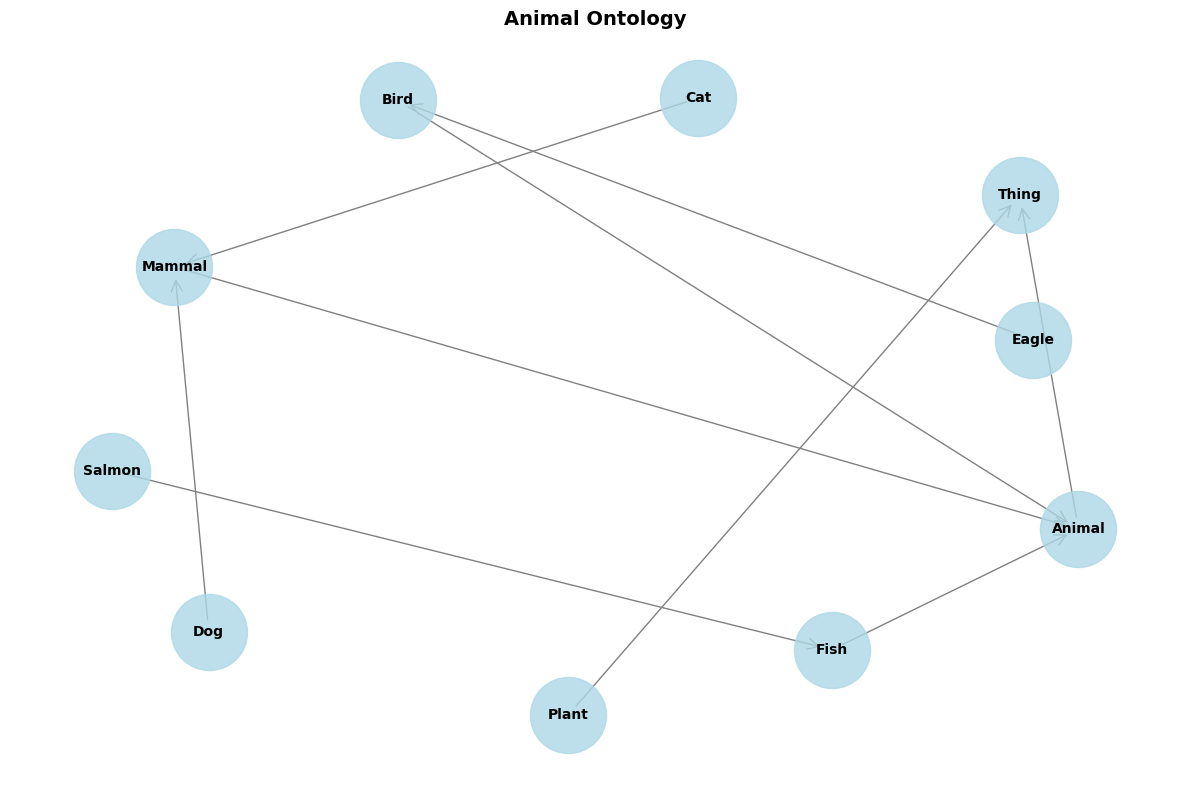



📋 Ontology Hierarchy:
Plant [alive, photosynthesis]
Dog [domesticated, loyal, barks] → ['Buddy']
Cat [domesticated, meows, independent] → ['Whiskers']
Eagle [sharp_talons, carnivore, flies] → ['Bald Eagle']
Salmon [edible, swims_upstream] → ['Atlantic Salmon']


In [19]:
# Demo: Visualize the ontology
ontology.visualize_ontology("Animal Ontology")

# Print text hierarchy
print("\n")
ontology.print_hierarchy()

In [20]:
# Demo: Advanced reasoning queries
print("🧠 Advanced Ontological Reasoning:\n")

# Query 1: What are all the animals?
print("1. All animals (including subclasses):")
all_animals = ontology.get_descendants("Animal")
print(f"   {sorted(all_animals)}")

# Query 2: What are all instances of mammals?
print("\n2. All mammal instances (including subclass instances):")
mammal_instances = ontology.query_instances("Mammal")
print(f"   {sorted(mammal_instances)}")

# Query 3: What properties do all dogs have?
print("\n3. All properties of dogs (direct + inherited):")
dog_properties = ontology.get_all_properties("Dog")
print(f"   {sorted(dog_properties)}")

# Query 4: What's the ancestry of a specific concept?
print("\n4. Ancestry chain for 'Dog':")
dog_ancestors = ontology.get_ancestors("Dog")
print(f"   Dog IS-A {' IS-A '.join(reversed(dog_ancestors))}")

print("\n💡 This demonstrates how ontological approaches enable systematic reasoning!")

🧠 Advanced Ontological Reasoning:

1. All animals (including subclasses):
   ['Thing']

2. All mammal instances (including subclass instances):
   []

3. All properties of dogs (direct + inherited):
   ['barks', 'domesticated', 'loyal']

4. Ancestry chain for 'Dog':
   Dog IS-A 

💡 This demonstrates how ontological approaches enable systematic reasoning!


---

# 🎯 Summary: Traditional NLP in Action

## What We've Implemented:

1. **🌐 Knowledge Graph Explorer**: Real-world semantic relationships (like Google Knowledge Graph)
2. **📖 WordNet Browser**: Lexicographic sense organization and similarity
3. **🔧 LCS Parser**: Decompositional verb meaning analysis
4. **🎯 WSD System**: Context-based sense disambiguation
5. **🌳 Ontology Reasoner**: Property inheritance and logical reasoning

## 💡 Key Insights:

- **Lexicographic approaches** provide structured, interpretable meaning representations
- **Decompositional approaches** reveal systematic patterns in verb meanings
- **Ontological approaches** enable logical reasoning through inheritance
- **WSD systems** show why context is crucial for disambiguation
- **Knowledge graphs** demonstrate how these approaches scale to real applications

## 🚀 Looking Forward:

These traditional approaches laid the foundation for modern NLP:
- **Week 8**: Machine learning methods that automate these approaches
- **Week 9**: Distributional semantics that learns meaning from data
- **Week 10+**: Neural approaches that combine the best of both worlds

The symbolic systems you've built here are still used in:
- Search engines (Google Knowledge Graph)
- Voice assistants (structured knowledge)
- Domain-specific applications (medical, legal, scientific)
- Hybrid AI systems (combining symbolic and statistical approaches)

---

**🔬 Try It Yourself**: 
- Modify the knowledge graph queries for your research domain
- Add new verbs to the LCS parser
- Extend the WSD system with more words and senses
- Build domain-specific ontologies
- Compare these approaches on the same semantic task!